In [1]:
import numpy as np
import matplotlib.pyplot as plt
from specs import *
from meer21cm import MockSimulation
from meer21cm.telescope import dish_beam_sigma
from scipy.optimize import curve_fit
from meer21cm.power import bin_3d_to_cy, bin_3d_to_1d
from matplotlib.colors import LogNorm
import glob
from astropy.cosmology import Planck18
import matplotlib.ticker as tck
from meer21cm.util import dft_matrix

In [2]:
def get_k_modes():
    mock = get_mock(0)    
    mock.downres_factor_transverse = ps_downres_transverse
    mock.downres_factor_radial = ps_downres_radial
    mock.get_enclosing_box()
    kperp_1 = mock.k_perp.copy()
    kpara_1 = mock.k_para.copy()
    kmode_1 = mock.k_mode.copy()
    kvec_1 = mock.k_vec.copy()
    return kperp_1, kpara_1, kmode_1, kvec_1

In [3]:
karr = get_k_modes()
kperp, kpara, kmode, kvec = karr

In [4]:
file_arr = glob.glob('/users/ztchen/scratch3/validation/full_sim_seed_*[0-9].npz')

In [5]:
k_xy_sel = (
    (np.abs(kvec[0])<0.04)[:,None,None] 
    * (np.abs(kvec[0])>0.01)[:,None,None] 
    * (np.abs(kvec[1])<0.04)[None,:,None]
    * (np.abs(kvec[1])>0.01)[None,:,None] 
    * (np.abs(kvec[2])<10)[None,None,:]
)
k_xy_sel[0] = 0.0
k_xy_sel[:,0] = 0.0
k_xy_sel[:,:,0] = 0.0
k_cy_sel = np.ones_like(k_xy_sel)
k_cy_sel[0] = 0.0
k_cy_sel[:,0] = 0.0
k_cy_sel[:,:,0] = 0.0

In [6]:
phi3d_arr = []
phimod3d_arr = []
pg3d_arr = []
pgmod3d_arr = []
pcross3d_arr = []
pcrossmod3d_arr = []
phiclean3d_arr = []
pcrossclean3d_arr = []
Rmat_arr = []
power_before_arr = []
power_after_arr = []
for file in file_arr:
    data = np.load(file)
    phi3d_arr.append(data['phi3d'])
    phimod3d_arr.append(data['phimod3d'])
    pg3d_arr.append(data['pg3d'])
    pgmod3d_arr.append(data['pgmod3d'])
    pcross3d_arr.append(data['pcross3d'])
    pcrossmod3d_arr.append(data['pcrossmod3d'])
    phiclean3d_arr.append(data['phiclean3d'])
    pcrossclean3d_arr.append(data['pxclean3d'])
    Rmat_arr.append(data['R_mat'])
    power_before_arr.append(data['power_tf_before'])
    power_after_arr.append(data['power_tf_after'])

In [7]:
phi3d_arr = np.array(phi3d_arr)
phimod3d_arr = np.array(phimod3d_arr)[0][None]
pg3d_arr = np.array(pg3d_arr)
pgmod3d_arr = np.array(pgmod3d_arr)[0][None]
pcross3d_arr = np.array(pcross3d_arr)
pcrossmod3d_arr = np.array(pcrossmod3d_arr)[0][None]
phiclean3d_arr = np.array(phiclean3d_arr)
pcrossclean3d_arr = np.array(pcrossclean3d_arr)
Rmat_arr = np.array(Rmat_arr)
power_before_arr = np.array(power_before_arr)
power_after_arr = np.array(power_after_arr)


In [8]:
phimock_cy = get_cy(phi3d_arr,karr,weights=k_cy_sel)
pmodelcy_arr = get_cy(phimod3d_arr,karr,weights=k_cy_sel)
pgmock_cy = get_cy(pg3d_arr,karr,weights=k_cy_sel)
pgmodcy_arr = get_cy(pgmod3d_arr,karr,weights=k_cy_sel)
pcrossmock_cy = get_cy(pcross3d_arr,karr,weights=k_cy_sel)
pcrossmodcy_arr = get_cy(pcrossmod3d_arr,karr,weights=k_cy_sel)
phicleanmock_cy = get_cy(phiclean3d_arr,karr,weights=k_cy_sel)
pcrosscleanmock_cy = get_cy(pcrossclean3d_arr,karr,weights=k_cy_sel)

/users/ztchen/meer21cm/src/meer21cm/power.py:2067: RuntimeWarning: invalid value encountered in divide
  pscy = pscy / np.sum(weights, 0)[None]


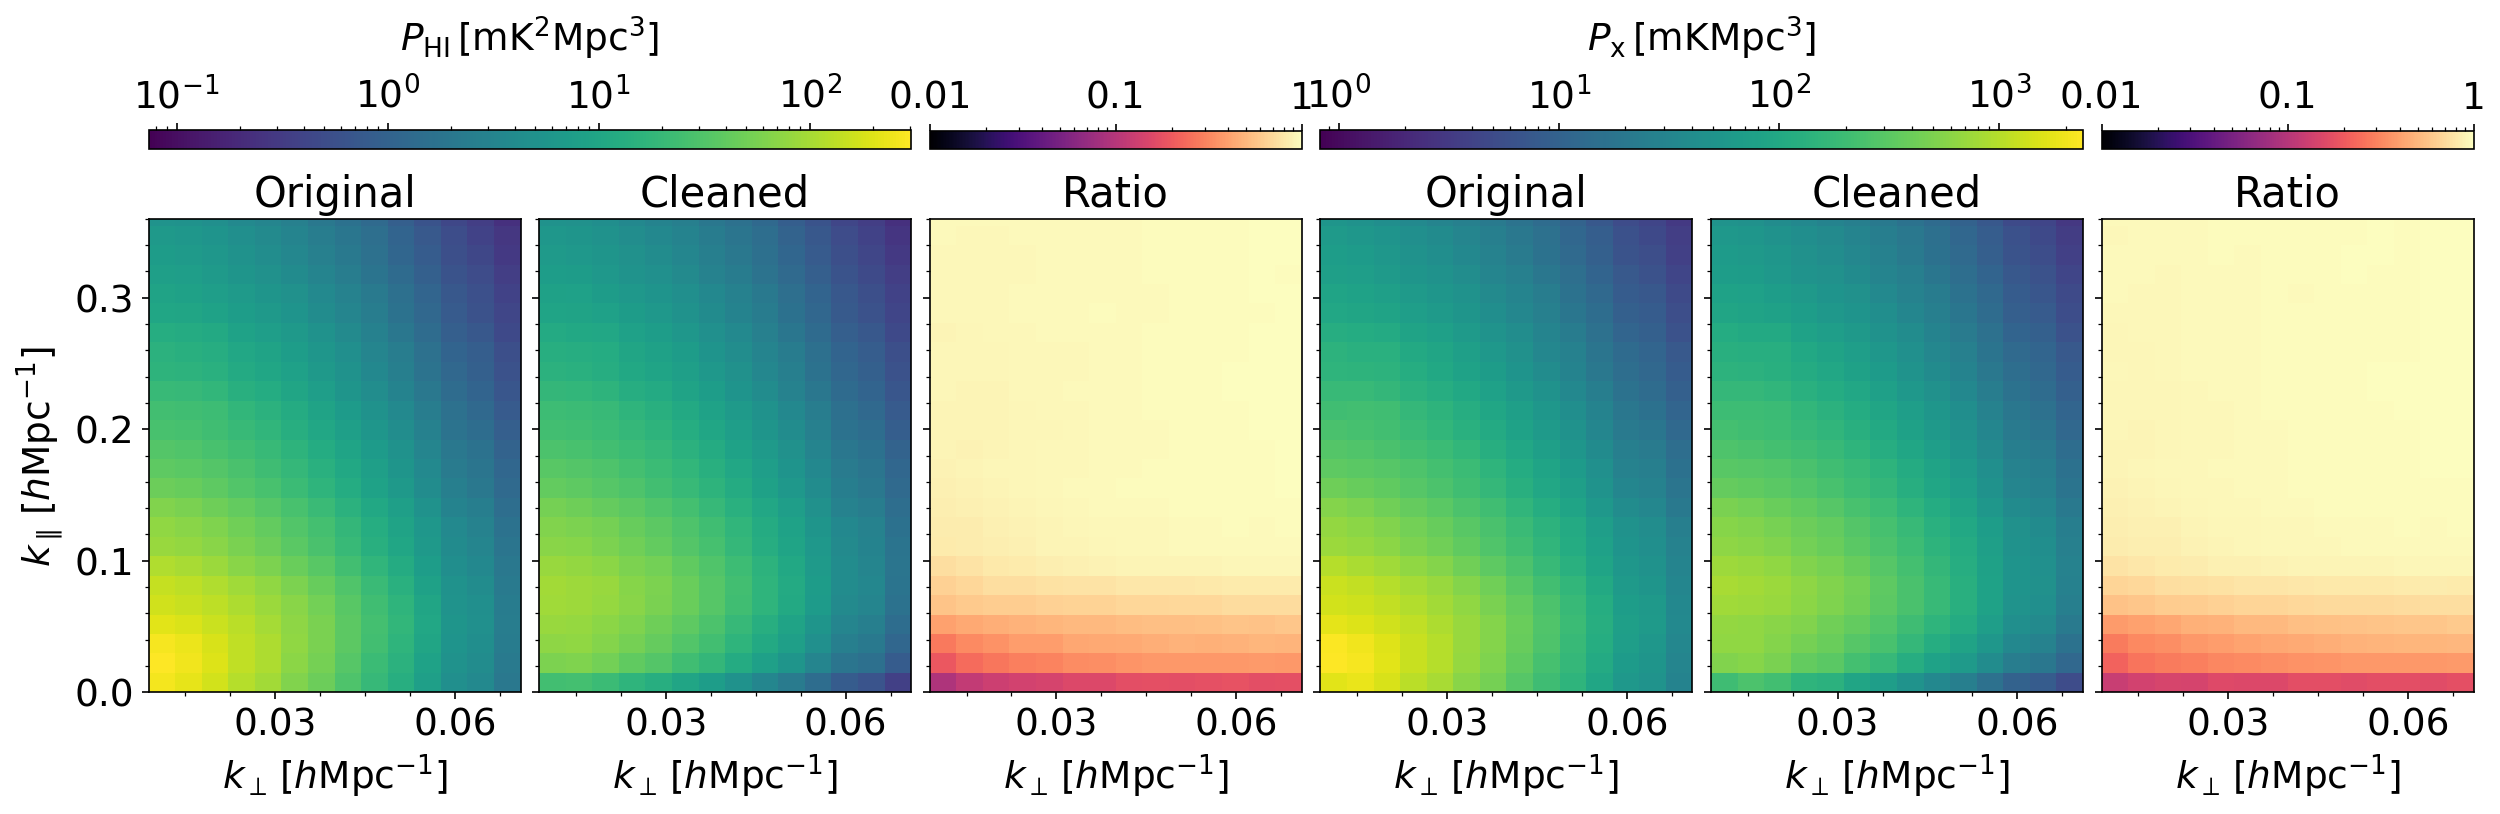

In [9]:
plt.rcParams['font.size'] = 18
fig, axes = plt.subplots(1, 6,figsize=(20,5),gridspec_kw={'wspace':0.05},dpi=150)
pmockarr = [phimock_cy*1e6,pcrossmock_cy*1e3]
pmodelarr = [phicleanmock_cy*1e6,pcrosscleanmock_cy*1e3]
pmockarr = np.array(pmockarr) * Planck18.h**3
pmodelarr = np.array(pmodelarr) * Planck18.h**3
ylabelarr= [
    r'$P_{\rm HI}\,[{\rm mK^2 Mpc^3}]$',
    r'$P_{\rm x}\,[{\rm mK Mpc^3}]$',
]
for ax in axes:
    ax.set_ylim(0,0.36)
for i in range(2):
    xbins = kperpbins / Planck18.h
    ybins = kparabins / Planck18.h
    pdatacy = pmockarr[i]
    pmodcy = pmodelarr[i]
    arr = np.array([
        (pdatacy.T),
        (pmodcy.T),
    ])
    vmin = np.nanmin(arr[:,:35])
    if vmin<0:
        vmin = 1
    vmax = np.nanmax(arr[:,:35])
    axes[0+i*3].pcolormesh(
        xbins,
        ybins,
        arr[0],
        norm=LogNorm(vmin=vmin, vmax=vmax)
    )
    axes[0+i*3].set_title('Original',fontsize=20)
    if i>0:
        axes[0+i*3].set_yticklabels([])
    else:
        axes[0+i*3].set_ylabel(r'$k_\parallel\,[h{\rm Mpc^{-1}}]$')
    im = axes[1+i*3].pcolormesh(
        xbins,
        ybins,
        arr[1],
        norm=LogNorm(vmin=vmin, vmax=vmax)
    )
    axes[1+i*3].set_yticklabels([])
    axes[1+i*3].set_title('Cleaned',fontsize=20)
    cbar = plt.colorbar(im,ax=axes[0+i*3:2+i*3],location="top",fraction=0.06,pad=0.12,aspect=40)
    cbar.set_label(ylabelarr[i],labelpad=12)
    im = axes[2+i*3].pcolormesh(
        xbins,
        ybins,
        arr[1]/arr[0],
        norm=LogNorm(vmin=1e-2, vmax=1),
        cmap="magma",
    )
    axes[2+i*3].set_yticklabels([])
    axes[2+i*3].set_title('Ratio',fontsize=20)
    cbar = plt.colorbar(im,ax=axes[2+i*3],location="top",fraction=0.06,pad=0.12)
    cbar.set_ticks([0.01,0.1,1])
    cbar.set_ticklabels(['0.01', '0.1', '1'])
    for j in range(3):
        axes[j+i*3].set_xticks([0.03,0.06])
        axes[j+i*3].yaxis.set_minor_locator(tck.AutoMinorLocator())
        axes[j+i*3].xaxis.set_minor_locator(tck.AutoMinorLocator())
for ax in axes:
    ax.set_xlabel(r'$k_\perp\,[h{\rm Mpc^{-1}}]$')
plt.savefig('plots/02_cy.pdf',dpi=150, bbox_inches = "tight")

In [10]:
num_split = 20
pxclean1darr_sel, keff_sel = get_1d(pcrossclean3d_arr,karr,weights=k_xy_sel,num_split=num_split)
px1darr_sel, keff_sel = get_1d(pcross3d_arr,karr,weights=k_xy_sel,num_split=num_split)
pxmod1darr_sel, keff_sel = get_1d(pcrossmod3d_arr,karr,weights=k_xy_sel)
phiclean1darr_sel, keff_sel = get_1d(phiclean3d_arr,karr,weights=k_xy_sel,num_split=num_split)
phi1darr_sel, keff_sel = get_1d(phi3d_arr,karr,weights=k_xy_sel,num_split=num_split)
phimod1darr_sel, keff_sel = get_1d(phimod3d_arr,karr,weights=k_xy_sel)
ptf_before, keff_sel = get_1d(power_before_arr,karr,weights=k_xy_sel,num_split=num_split)
ptf_after, keff_sel = get_1d(power_after_arr,karr,weights=k_xy_sel,num_split=num_split)
keff_sel = keff_sel / Planck18.h

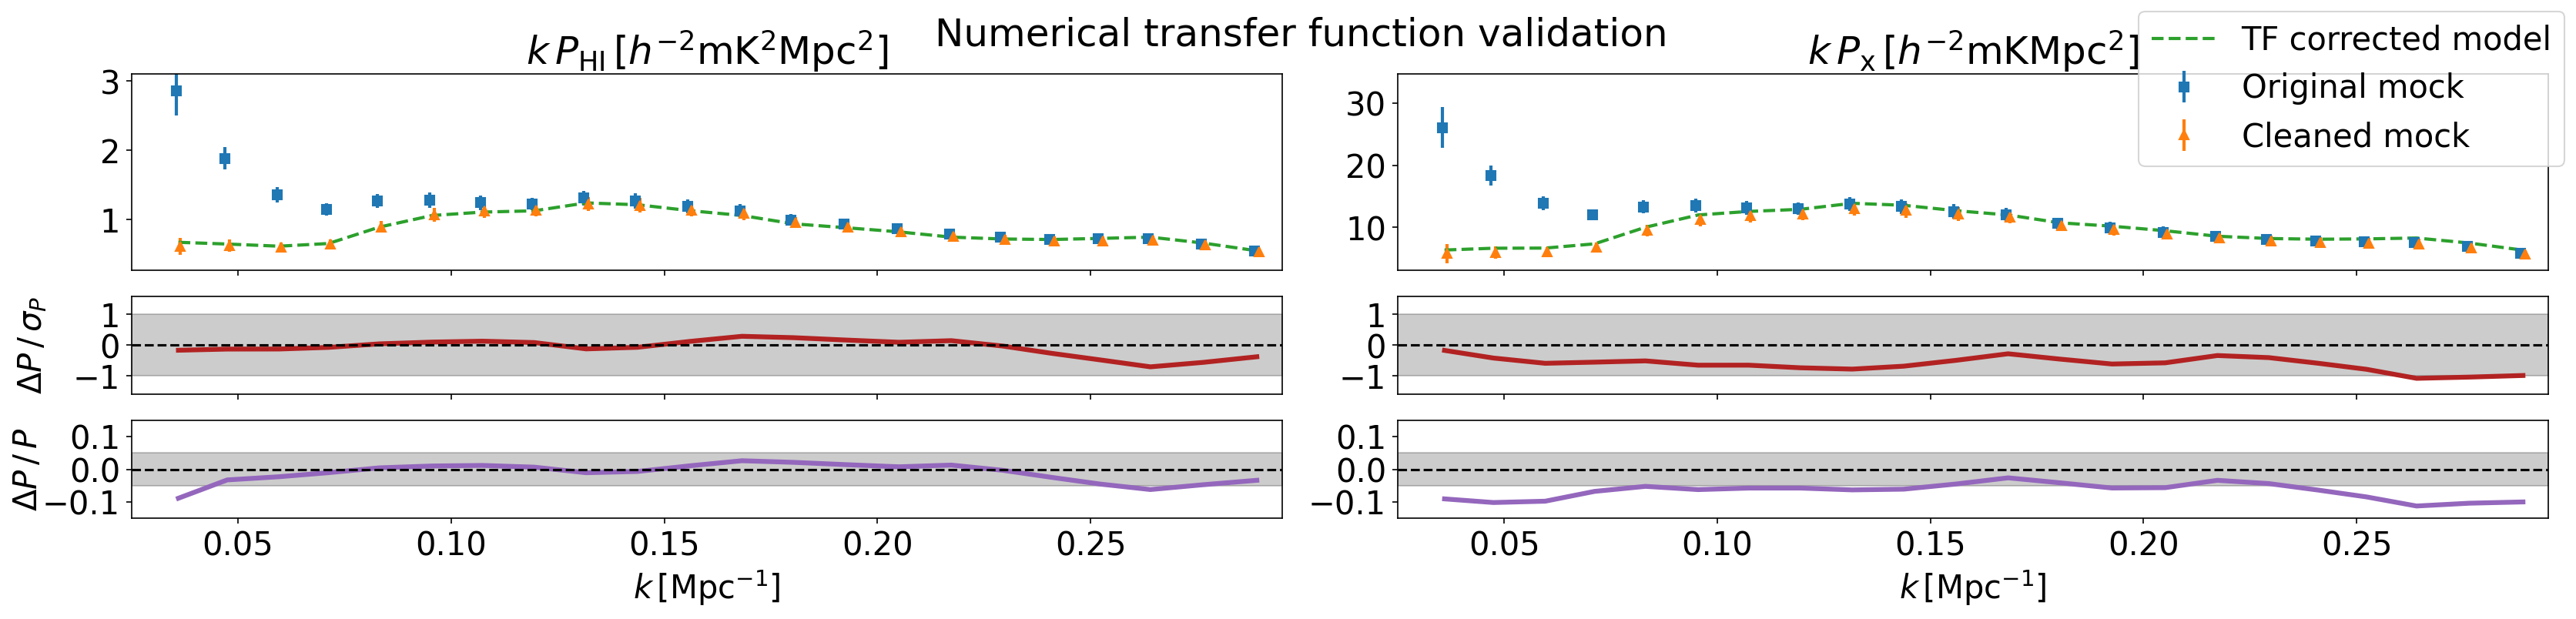

In [12]:
tf1darr_sel = (ptf_after/ptf_before).mean(0)
# the first k-mode is lost

# just for range
keff = np.array([0.03,0.29])
plt.rcParams['font.size'] = 20
fig,axes=plt.subplots(
    3,2,figsize=(27,5),sharex=True,
    height_ratios=[2,1,1],dpi=150,
    gridspec_kw={'wspace':0.1},
)
ratio_min,ratio_max = (-1.6,1.6)
pmockarr = [phi1darr_sel*1e6,px1darr_sel*1e3]
pcleanarr = [phiclean1darr_sel*1e6,pxclean1darr_sel*1e3]
pmodelarr = [
    (phimod1darr_sel*tf1darr_sel)*1e6,
    (pxmod1darr_sel*tf1darr_sel)*1e3]
pmockarr = np.array(pmockarr) * Planck18.h**3
pmodelarr = np.array(pmodelarr)[:,0] * Planck18.h**3
pcleanarr = np.array(pcleanarr) * Planck18.h**3
titlearr = [r'HI power',r'Cross power']
ylabelarr= [
    r'$k\,P_{\rm HI}\,[h^{-2}{\rm mK^2 Mpc^2}]$',
    r'$k\,P_{\rm x}\,[h^{-2}{\rm mK Mpc^2}]$',
]
for i in range(2):
    pdatad = pmockarr[i]
    pmodd = pmodelarr[i]
    pcleand = pcleanarr[i]
    axes[0,i].errorbar(
        keff_sel-0.0005,
        pdatad.mean(axis=0) * keff_sel,
        yerr=pdatad.std(axis=0) * keff_sel / np.sqrt(10),
        ls='None',
        marker='s',
        label="Original mock",
        elinewidth=2,
    )
    axes[0,i].errorbar(
        keff_sel+0.0005,
        pcleand.mean(axis=0) * keff_sel,
        yerr=pcleand.std(axis=0) * keff_sel / np.sqrt(10),
        ls='None',
        marker='^',
        label="Cleaned mock",
        elinewidth=2,
    )
    axes[0,i].plot(keff_sel, pmodd * keff_sel, label="TF corrected model", ls="--",lw=2)
    axes[0,i].set_ylim(
        np.nanmin(pmodd * keff_sel) * 0.5, 
        np.nanmax(pmodd * keff_sel) * 2.5)
    axes[0,i].set_title(ylabelarr[i])
    axes[1,i].plot(
        keff_sel,
        (pcleand.mean(axis=0)- pmodd) / (pdatad.std(axis=0)) * np.sqrt(10),
        lw=3,
        color='firebrick',
    )
    axes[1,i].fill_between(
        np.linspace(keff.min() - 0.005, keff.max() + 0.005, 100),
        -1,
        1,
        color="black",
        alpha=0.2,
    )
    axes[1,i].axhline(0, color="black", ls="--")
    axes[1,i].set_xlim(keff.min()-0.005,keff.max()+0.005)
    axes[1,i].set_ylim(ratio_min,ratio_max)
    if i == 0:
        axes[1,i].set_ylabel(r'$\Delta P \, / \,\sigma_P$',labelpad=15)
    axes[2,i].plot(
        keff_sel,
        (pcleand.mean(axis=0)) / (pmodd) - 1,
        lw=3,
        color='C4',
        #yerr=(pdatad.std(axis=0)) / (pmodd),
    )
    axes[2,i].axhline(0, color="black", ls="--")
    axes[2,i].fill_between(
        np.linspace(keff.min() - 0.005, keff.max() + 0.005, 100),
        -0.05,
        0.05,
        color="black",
        alpha=0.2,
    )
    axes[2,i].set_xlim(keff.min() - 0.005, keff.max() + 0.005)
    axes[2,i].set_ylim(-0.15, 0.15)
    axes[2,i].set_xlabel(r'$k\,[{\rm Mpc^{-1}}]$')
    if i == 0:
        axes[2,i].set_ylabel(r'$\Delta P \, / \,P$',labelpad=-1)
    if i == 1:
        axes[0,i].legend(loc='upper left', bbox_to_anchor=[0.63,1.4])
fig.suptitle("Numerical transfer function validation")
        
plt.savefig('plots/02_1d.pdf',dpi=150, bbox_inches = "tight")

In [13]:
mock = get_mock(0)
mock.downres_factor_transverse = ps_downres_transverse
mock.downres_factor_radial = ps_downres_radial
mock.get_enclosing_box()
xarr = mock.cosmo.comoving_distance(mock.z_ch).value
comov_dist = xarr.max() - xarr.min()
F_mat = dft_matrix(mock.nu.shape[0])
R_mat_fourier = np.zeros(Rmat_arr.shape,dtype='complex')
for i,R_i in enumerate(Rmat_arr):
    R_mat_fourier[i] = F_mat @ R_i @ np.conj(F_mat).T / len(R_i)
Hab = (R_mat_fourier.mean(0) * np.conj(R_mat_fourier).mean(0)).real
# naive approximation along los
k_para_pseudo = np.fft.fftfreq(mock.nu.size,d=comov_dist/mock.nu.size) * 2 * np.pi
# interpolate this Hab
from scipy.interpolate import RegularGridInterpolator
xx = np.fft.fftshift(k_para_pseudo)
xarr,yarr = np.meshgrid(mock.k_para,mock.k_para)
Hab_interp = RegularGridInterpolator((xx,xx),np.fft.fftshift(Hab))((xarr,yarr))
signal_loss = np.diagonal(R_mat_fourier.mean(0)@np.conj(R_mat_fourier.mean(0)).T).real
tf_interp = interp1d(
    np.fft.fftshift(k_para_pseudo),
    np.fft.fftshift(signal_loss)
)
tf_kpara = tf_interp(mock.k_para)
Hab= Hab_interp / Hab_interp.sum(1)[:,None] * tf_kpara[:,None]

In [14]:
phimod1darr_hab, k_hab = get_1d(
    np.einsum(
        'ij,nabj->nabi',
        Hab,
        phimod3d_arr,
    ),karr,weights=k_xy_sel
)
pxmod1darr_hab,k_hab = get_1d(
    (pcrossmod3d_arr * Hab.sum(1)[None,None,:]),
    karr,weights=k_xy_sel
)

In [15]:
k_hab = k_hab / Planck18.h

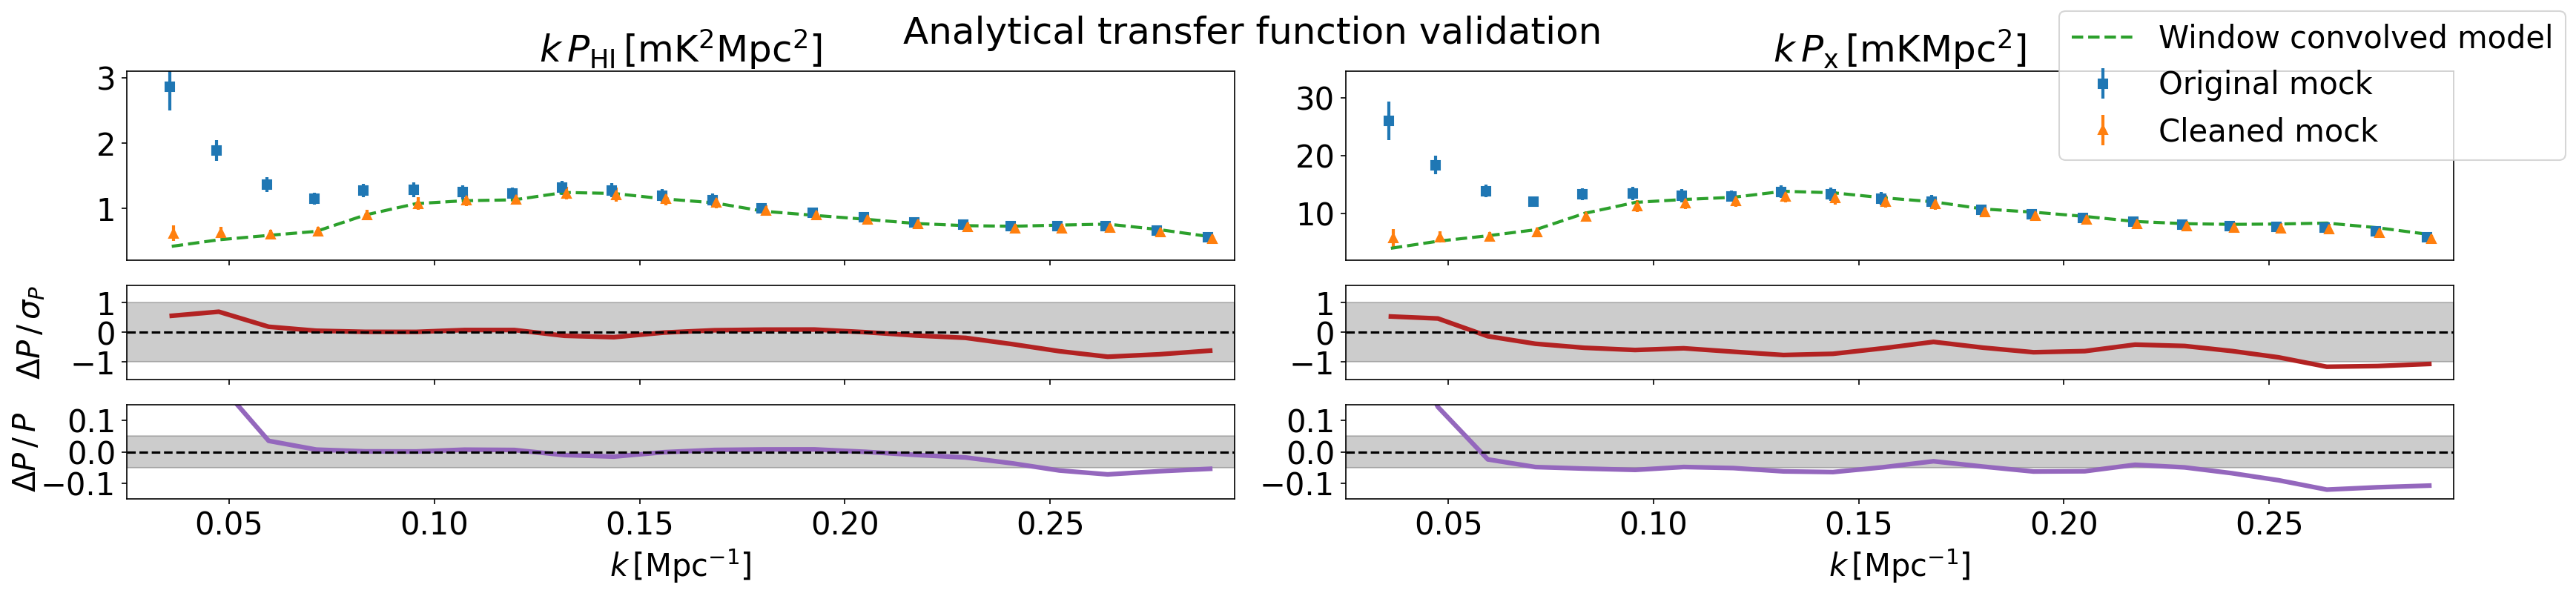

In [16]:
plt.rcParams['font.size'] = 20
fig,axes=plt.subplots(
    3,2,figsize=(27,5),sharex=True,
    height_ratios=[2,1,1],dpi=150,
    gridspec_kw={'wspace':0.1},
)
ratio_min,ratio_max = (-1.6,1.6)
pmockarr = [phi1darr_sel*1e6,px1darr_sel*1e3]
pcleanarr = [phiclean1darr_sel*1e6,pxclean1darr_sel*1e3]
pmodelarr = [
    (phimod1darr_hab)*1e6,
    (pxmod1darr_hab)*1e3]
pmockarr = np.array(pmockarr) * Planck18.h**3
pmodelarr = np.array(pmodelarr)[:,0] * Planck18.h**3
pcleanarr = np.array(pcleanarr) * Planck18.h**3
titlearr = [r'HI power',r'Cross power']
ylabelarr= [
    r'$k\,P_{\rm HI}\,[{\rm mK^2 Mpc^2}]$',
    r'$k\,P_{\rm x}\,[{\rm mK Mpc^2}]$',
]
for i in range(2):
    pdatad = pmockarr[i]
    pmodd = pmodelarr[i]
    pcleand = pcleanarr[i]
    axes[0,i].errorbar(
        k_hab-0.0005,
        pdatad.mean(axis=0) * k_hab,
        yerr=pdatad.std(axis=0) * k_hab / np.sqrt(10),
        ls='None',
        marker='s',
        label="Original mock",
        elinewidth=2,
    )
    axes[0,i].errorbar(
        k_hab+0.0005,
        pcleand.mean(axis=0) * k_hab,
        yerr=pcleand.std(axis=0) * k_hab / np.sqrt(10),
        ls='None',
        marker='^',
        label="Cleaned mock",
        elinewidth=2,
    )
    axes[0,i].plot(k_hab, pmodd * k_hab, label="Window convolved model", ls="--",lw=2)
    axes[0,i].set_ylim(
        np.nanmin(pmodd * keff_sel) * 0.5, 
        np.nanmax(pmodd * keff_sel) * 2.5)
    axes[0,i].set_title(ylabelarr[i])
    axes[1,i].plot(
        k_hab,
        (pcleand.mean(axis=0)- pmodd) / (pdatad.std(axis=0)) * np.sqrt(10),
        lw=3,
        color='firebrick',
    )
    axes[1,i].fill_between(
        np.linspace(keff.min() - 0.005, keff.max() + 0.005, 100),
        -1,
        1,
        color="black",
        alpha=0.2,
    )
    axes[1,i].axhline(0, color="black", ls="--")
    axes[1,i].set_xlim(keff.min()-0.005,keff.max()+0.005)
    axes[1,i].set_ylim(ratio_min,ratio_max)
    if i == 0:
        axes[1,i].set_ylabel(r'$\Delta P \, / \,\sigma_P$',labelpad=15)
    axes[2,i].plot(
        k_hab,
        (pcleand.mean(axis=0)) / (pmodd) - 1,
        lw=3,
        color='C4',
        #yerr=(pdatad.std(axis=0)) / (pmodd),
    )
    axes[2,i].axhline(0, color="black", ls="--")
    axes[2,i].fill_between(
        np.linspace(keff.min() - 0.005, keff.max() + 0.005, 100),
        -0.05,
        0.05,
        color="black",
        alpha=0.2,
    )
    axes[2,i].set_xlim(keff.min() - 0.005, keff.max() + 0.005)
    axes[2,i].set_ylim(-0.15, 0.15)
    axes[2,i].set_xlabel(r'$k\,[{\rm Mpc^{-1}}]$')
    if i == 0:
        axes[2,i].set_ylabel(r'$\Delta P \, / \,P$',labelpad=-1)
    if i == 1:
        axes[0,i].legend(loc='upper left', bbox_to_anchor=[0.63,1.4])
fig.suptitle("Analytical transfer function validation")
    
plt.savefig('plots/02_1d_hab.pdf',dpi=150, bbox_inches = "tight")